# Brain v. Blood DMRs
using output from: `make_segment_and_DMR_BEDs.py`

##### Modules

In [5]:
import os
import pandas as pd
import numpy as np
from pybedtools import BedTool

import upsetplot
from matplotlib_venn import venn2, venn2_circles
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib import font_manager
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors

from statsmodels.stats.multitest import multipletests
import scipy.stats as stats

##### Functions

In [46]:
def plot_key_from_pair(pair: str) -> str:
    """Convert filename pair into the plot key.

    Your file naming has PPMI first for two pairs, but you want HBCC first in the plot.
    """
    if pair.startswith("PPMI_3404_v_"):
        a, b = pair.split("_v_", 1)
        return f"{b}_v_{a}"
    return pair

def bed_count(path: str) -> int:
    """Count intervals in a BED (or BED-like) file."""
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    return BedTool(path).count()

def plot_grouped_upset_from_counts(
    counts,
    set_sizes=None,
    comparison_order=None,
    colors=None,  # list of colors (len == #comparisons)
    combo_order=("modkit_only", "dss_only", "both"),
    combo_labels=("modkit only", "DSS only", "modkit ∩ DSS"),
    title=None,
    show_left_legend=True,
    # ---- new style controls ----
    label_fs=14,
    tick_fs=12,
    legend_fs=12,
    title_fs=16,
    dot_size=150,
    line_w=2.5,
):
    """Grouped UpSet-style plot for 2 methods (modkit, DSS) across multiple comparisons.

    Input is counts only; optional set_sizes for left panel.

    Parameters
    ----------
    counts : dict
        comp -> dict/tuple of (modkit_only, dss_only, both)
    set_sizes : dict or None
        comp -> (modkit_total, dss_total)  (DMR call counts)
    colors : list or None
        One color per comparison; used in BOTH left and top panels.
    label_fs, tick_fs, legend_fs, title_fs : int
        Font sizes.
    dot_size : int
        Dot size for the membership matrix.
    line_w : float
        Connector line width for intersections.
    """

    if comparison_order is None:
        comparison_order = list(counts.keys())

    nC = len(comparison_order)
    nComb = len(combo_order)

    if colors is None:
        colors = [None] * nC
    elif len(colors) != nC:
        raise ValueError(f"colors must have length {nC} (one per comparison)")

    # ---- Build data matrix for top bars ----
    data = np.zeros((nC, nComb), dtype=float)
    for i, comp in enumerate(comparison_order):
        v = counts[comp]
        if isinstance(v, dict):
            data[i, :] = [v[k] for k in combo_order]
        else:
            if len(v) != nComb:
                raise ValueError(f"{comp}: expected {nComb} values, got {len(v)}")
            data[i, :] = v

    show_left = set_sizes is not None

    fig_w = 10 if show_left else 7.5
    fig = plt.figure(figsize=(fig_w, 6))

    if show_left:
        gs = fig.add_gridspec(
            nrows=2,
            ncols=2,
            width_ratios=[1.4, 3.6],
            height_ratios=[3.0, 1.4],
            wspace=0.25,
            hspace=0.1,  # <-- more vertical space
        )
        ax_set = fig.add_subplot(gs[:, 0])
        ax_bar = fig.add_subplot(gs[0, 1])
        ax_mat = fig.add_subplot(gs[1, 1], sharex=ax_bar)
    else:
        gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[3.0, 1.4], hspace=0.1)
        ax_bar = fig.add_subplot(gs[0, 0])
        ax_mat = fig.add_subplot(gs[1, 0], sharex=ax_bar)
        ax_set = None

    # =========================
    # LEFT PANEL: grouped bars with ONLY 2 y ticks (modkit, DSS)
    # =========================
    if show_left:
        modkit_sizes = np.zeros(nC, dtype=float)
        dss_sizes = np.zeros(nC, dtype=float)

        for i, comp in enumerate(comparison_order):
            ss = set_sizes[comp]
            if isinstance(ss, dict):
                modkit_sizes[i] = ss["modkit_total"]
                dss_sizes[i] = ss["dss_total"]
            else:
                if len(ss) != 2:
                    raise ValueError(
                        f"{comp}: set_sizes must have 2 values (modkit_total, dss_total)"
                    )
                modkit_sizes[i], dss_sizes[i] = ss

        # Two groups: y=1 (modkit), y=0 (DSS)
        y_groups = np.array([1.0, 0.0])

        # group height and per-comparison offsets within each group
        total_group_height = 0.75
        bar_h = total_group_height / nC
        offsets = (np.arange(nC) - (nC - 1) / 2.0) * bar_h

        # Plot modkit totals
        for i, comp in enumerate(comparison_order):
            ax_set.barh(
                y_groups[0] + offsets[i],
                modkit_sizes[i],
                height=bar_h * 0.92,
                color=colors[i],
                label=comp if show_left_legend else None,
            )

        # Plot DSS totals
        for i, comp in enumerate(comparison_order):
            ax_set.barh(
                y_groups[1] + offsets[i],
                dss_sizes[i],
                height=bar_h * 0.92,
                color=colors[i],
            )

        ax_set.set_yticks([1.0, 0.0])
        ax_set.set_yticklabels(["modkit", "DSS"], fontsize=tick_fs)
        ax_set.set_xlabel("Set size", fontsize=label_fs)
        ax_set.tick_params(axis="x", labelsize=tick_fs)
        ax_set.spines["top"].set_visible(False)
        ax_set.spines["right"].set_visible(False)
        ax_set.grid(axis="x", linestyle=":", alpha=0.3)

        ax_set.legend(fontsize=legend_fs, bbox_to_anchor=(1.5, -.1))

    # =========================
    # TOP PANEL: grouped intersection bars
    # =========================
    x = np.arange(nComb)
    total_group_width = 0.8
    bar_w = total_group_width / nC
    x_offsets = (np.arange(nC) - (nC - 1) / 2.0) * bar_w

    for i, comp in enumerate(comparison_order):
        ax_bar.bar(
            x + x_offsets[i],
            data[i, :],
            width=bar_w * 0.95,
            label=comp,
            color=colors[i],
        )

    ax_bar.set_ylabel("Intersection size", fontsize=label_fs)
    ax_bar.tick_params(axis="y", labelsize=tick_fs)

    # Remove x ticks/labels from top plot entirely
    ax_bar.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False)

    # ax_bar.legend(frameon=False, fontsize=legend_fs)
    ax_bar.spines["right"].set_visible(False)
    ax_bar.spines["top"].set_visible(False)
    ax_bar.grid(axis="y", linestyle=":", alpha=0.4)

    if title:
        ax_bar.set_title(title, fontsize=title_fs, pad=10)

    # =========================
    # BOTTOM PANEL: dot matrix (fixed for 2 sets)
    # =========================
    membership = {
        "modkit_only": (1, 0),
        "dss_only": (0, 1),
        "both": (1, 1),
    }

    for j, combo in enumerate(combo_order):
        m_mod, m_dss = membership[combo]

        ax_mat.scatter([j, j], [1, 0], s=dot_size, color="lightgray", zorder=1)
        if m_mod:
            ax_mat.scatter(j, 1, s=dot_size, color="black", zorder=2)
        if m_dss:
            ax_mat.scatter(j, 0, s=dot_size, color="black", zorder=2)
        if m_mod and m_dss:
            ax_mat.plot([j, j], [0, 1], color="black", linewidth=line_w, zorder=0)

    ax_mat.set_yticks([1, 0])
    ax_mat.set_yticklabels(["modkit", "DSS"], fontsize=tick_fs)
    ax_mat.set_xticks(x)
    ax_mat.set_xticklabels(combo_labels, fontsize=tick_fs)
    ax_mat.set_xlim(-0.5, nComb - 0.5)
    ax_mat.set_ylim(-0.7, 1.7)
    ax_mat.spines["right"].set_visible(False)
    ax_mat.spines["top"].set_visible(False)
    ax_mat.spines["left"].set_visible(False)
    ax_mat.tick_params(axis="y", length=0)

    plt.show()


In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_sniffcell_heatmap(
    df0: pd.DataFrame,
    comparison_order,
    user_sets=("modkit_only", "dss_only", "shared"),
    collection="sniffcell",
    filename_col="filename",
    odds_col="oddsRatio",
    qval_col="qValue",
    test_col="test",
    userset_col="userSet",
    qval_star=0.05,
    agg="median",  # 'median' or 'mean'
    log2_or=False,
    cmap="viridis",
    figsize=(11, 6),
    title="sniffcell enrichment heatmap (LOLA)",
    vmin=None,
    vmax=None,
    show_colorbar=True,
):
    """Heatmap of sniffcell odds ratios with stars for significance.

    Layout: rows = cell types, columns = user_sets (modkit_only/dss_only/shared)
    Values: aggregated odds ratio across comparisons (median by default)
    Stars: put a '*' in the cell if ANY comparison has qValue < qval_star
           (and that row exists for that cell_type/userSet)

    Notes
    -----
    - Odds ratios are positive; you can set log2_or=True to improve dynamic range.
    - If you prefer stricter significance, change star rule to (all comparisons significant)
      by editing the `sig_rule` section.
    """

    # Filter
    df = df0[df0["collection"] == collection].copy()
    df = df[df[userset_col].isin(user_sets)].copy()
    df = df[df[test_col].isin(comparison_order)].copy()

    # tidy labels
    df["cell_type"] = df[filename_col].astype(str).str.replace(".bed", "", regex=False)

    # Ensure ordering
    cell_types = sorted(df["cell_type"].unique().tolist())
    df["cell_type"] = pd.Categorical(df["cell_type"], categories=cell_types, ordered=True)
    df[userset_col] = pd.Categorical(df[userset_col], categories=list(user_sets), ordered=True)
    df[test_col] = pd.Categorical(df[test_col], categories=list(comparison_order), ordered=True)

    # Aggregate odds ratio across comparisons
    agg_fn = np.median if agg == "median" else np.mean
    heat = (
        df.groupby(["cell_type", userset_col], as_index=False)
        .agg(or_agg=(odds_col, agg_fn))
        .pivot(index="cell_type", columns=userset_col, values="or_agg")
        .reindex(index=cell_types, columns=list(user_sets))
    )

    # Significance rule for star: ANY comparison has q < threshold
    sig = (
        df.assign(sig=df[qval_col] < qval_star)
        .groupby(["cell_type", userset_col], as_index=False)
        .agg(any_sig=("sig", "any"))
        .pivot(index="cell_type", columns=userset_col, values="any_sig")
        .reindex(index=cell_types, columns=list(user_sets))
        .fillna(False)
    )

    # Optional transform
    plot_vals = heat.copy()
    if log2_or:
        # avoid log2(0) if any OR is 0 (shouldn't happen, but just in case)
        plot_vals = np.log2(plot_vals.astype(float).clip(lower=1e-12))

    # Plot
    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(plot_vals.to_numpy(), aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)

    # Ticks/labels
    ax.set_yticks(np.arange(len(cell_types)))
    ax.set_yticklabels(cell_types)

    # Pretty column labels
    col_labels = {
        "modkit_only": "modkit only",
        "dss_only": "DSS only",
        "shared": "modkit ∩ DSS",
    }
    ax.set_xticks(np.arange(len(user_sets)))
    ax.set_xticklabels([col_labels.get(u, u) for u in user_sets])

    ax.set_title(title)

    # Draw gridlines between cells (subtle)
    ax.set_xticks(np.arange(-0.5, len(user_sets), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(cell_types), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Add stars for significant cells
    for i, ct in enumerate(cell_types):
        for j, us in enumerate(user_sets):
            if bool(sig.loc[ct, us]):
                ax.text(j, i, "*", ha="center", va="center", color="white", fontsize=14, fontweight="bold")

    # Colorbar
    if show_colorbar:
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        if log2_or:
            cbar.set_label("log2(odds ratio)")
        else:
            cbar.set_label("odds ratio")

    plt.tight_layout()
    plt.show()


# -------------------------
# Example usage:
# plot_sniffcell_heatmap(
#     df0=df0,
#     comparison_order=comparison_order,
#     user_sets=("modkit_only", "dss_only", "shared"),
#     qval_star=0.05,
#     agg="median",
#     log2_or=False,   # consider True if OR range is huge
# )
# -------------------------


In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


def plot_sniffcell_heatmap(
    df0: pd.DataFrame,
    comparison_order,
    user_sets=("modkit_only", "dss_only", "shared"),
    collection="sniffcell",
    filename_col="filename",
    odds_col="oddsRatio",
    qval_col="qValue",
    test_col="test",
    userset_col="userSet",
    qval_star=0.05,
    log2_or=False,
    cmap="viridis",
    figsize=(8, 6),
    title="DMR enrichment of cell type marker regions",
    vmin=None,
    vmax=None,
    show_colorbar=True,
    # --- styling ---
    tick_fs=14,
    label_fs=14,
    title_fs=18,
    star_fs=24,
    star_color="darkorange",
    x_rotation=45,
    # --- ordering ---
    cell_type_order=None,
    # --- top group colors ---
    comparison_colors=None,  # list (len == n comparisons) or dict {comparison: color}
    top_bar_height=0.04,
):
    """Heatmap of sniffcell odds ratios with per-comparison stars.

    Layout
    ------
    rows = cell types
    columns = (comparison × userSet)  => e.g. 3 comparisons × 3 sets = 9 columns

    Values
    ------
    oddsRatio for each (cell_type, userSet, comparison)

    Stars
    -----
    Put a '*' in the cell if qValue < qval_star for that (cell_type, userSet, comparison).

    Extras
    ------
    A colored bar is drawn above the heatmap indicating which comparison each column belongs to.
    """

    # Filter
    df = df0[df0["collection"] == collection].copy()
    df = df[df[userset_col].isin(user_sets)].copy()
    df = df[df[test_col].isin(comparison_order)].copy()

    # tidy labels
    df["cell_type"] = df[filename_col].astype(str).str.replace(".bed", "", regex=False)

    # Row order: Neuron and Oligodendrocyte last unless user provides an order
    if cell_type_order is None:
        cell_types = sorted(df["cell_type"].unique().tolist())
        tail = []
        for name in ["Neuron", "Oligodendrocyte"]:
            if name in cell_types:
                cell_types.remove(name)
                tail.append(name)
        cell_types = cell_types + tail
    else:
        cell_types = list(cell_type_order)

    # Ensure ordering
    df["cell_type"] = pd.Categorical(df["cell_type"], categories=cell_types, ordered=True)
    df[userset_col] = pd.Categorical(df[userset_col], categories=list(user_sets), ordered=True)
    df[test_col] = pd.Categorical(df[test_col], categories=list(comparison_order), ordered=True)

    # Full column order (comparison_order × user_sets)
    col_order = pd.MultiIndex.from_product(
        [comparison_order, list(user_sets)],
        names=[test_col, userset_col],
    )

    # Heatmap values: one cell per (comparison, userSet)
    heat = (
        df.groupby(["cell_type", test_col, userset_col], as_index=False)
        .agg(or_val=(odds_col, "first"))
        .pivot(index="cell_type", columns=[test_col, userset_col], values="or_val")
        .reindex(index=cell_types)
        .reindex(columns=col_order)
    )

    # Significance mask: star per (comparison, userSet)
    sig = (
        df.assign(sig=df[qval_col] < qval_star)
        .groupby(["cell_type", test_col, userset_col], as_index=False)
        .agg(sig_val=("sig", "first"))
        .pivot(index="cell_type", columns=[test_col, userset_col], values="sig_val")
        .reindex(index=cell_types)
        .reindex(columns=col_order)
        .fillna(False)
    )

    plot_vals = heat.copy()
    if log2_or:
        plot_vals = np.log2(plot_vals.astype(float).clip(lower=1e-12))

    # Comparison colors for the top bar
    n_comp = len(comparison_order)
    n_set = len(user_sets)
    n_cols = n_comp * n_set

    if comparison_colors is None:
        # fall back to matplotlib tab colors
        comparison_colors = [None] * n_comp
    if isinstance(comparison_colors, dict):
        comp_color_list = [comparison_colors[c] for c in comparison_order]
    else:
        if len(comparison_colors) != n_comp:
            raise ValueError("comparison_colors must have length == len(comparison_order)")
        comp_color_list = list(comparison_colors)

    # Build the top-bar matrix of integers 0..n_comp-1 for each column
    top_ids = np.repeat(np.arange(n_comp), n_set)[None, :]

    # ---- Plot with a small top axis for group colors ----
    fig = plt.figure(figsize=figsize)

    # Use a 2-column GridSpec so the colorbar does NOT shrink the heatmap width
    # (which would misalign the top group-color bar).
    gs = fig.add_gridspec(
        nrows=2,
        ncols=2,
        height_ratios=[top_bar_height, 1.0],
        width_ratios=[1.0, 0.04],
        hspace=0.02,
        wspace=0.06,
    )

    ax_top = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0], sharex=ax_top)
    cax = fig.add_subplot(gs[1, 1])

    # Heatmap
    im = ax.imshow(
        plot_vals.to_numpy(),
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        extent=(-0.5, n_cols - 0.5, len(cell_types) - 0.5, -0.5),
    )

    # Top comparison color bar (align exactly to heatmap columns)
    ax_top.imshow(
        top_ids,
        aspect="auto",
        cmap=ListedColormap(comp_color_list),
        extent=(-0.5, n_cols - 0.5, 0.5, -0.5),
    )
    ax_top.set_xlim(-0.5, n_cols - 0.5)
    ax_top.set_yticks([])
    ax_top.set_xticks([])
    ax_top.tick_params(
    axis='both',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False)
    
    for spine in ax_top.spines.values():
        spine.set_visible(False)

    # Y ticks/labels
    ax.set_yticks(np.arange(len(cell_types)))
    ax.set_yticklabels(cell_types, fontsize=tick_fs)

    # X ticks/labels: show ONLY the userSet labels (repeated for each comparison)
    pretty_set = {
        "modkit_only": "modkit only",
        "dss_only": "DSS only",
        "shared": "modkit ∩ DSS",
    }

    # label each column with the userSet name
    ax.set_xticks(np.arange(n_cols))
    xticklabels = [pretty_set.get(us, us) for comp in comparison_order for us in user_sets]
    ax.set_xticklabels(xticklabels, fontsize=tick_fs, rotation=x_rotation, ha="right")

    # no comparison labels on axis (top bar encodes comparison)
    ax.tick_params(axis="x", which="major", pad=10, length=0)

    ax.set_title(title, fontsize=title_fs, pad=25)

    # Draw gridlines between cells without clobbering labeled ticks
    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(cell_types), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Add stars for significant cells (no bbox; high-contrast color)
    for i in range(sig.shape[0]):
        for j in range(sig.shape[1]):
            if bool(sig.iloc[i, j]):
                ax.text(
                    j,
                    i,
                    "*",
                    ha="center",
                    va="center",
                    color=star_color,
                    fontsize=star_fs,
                    fontweight="bold",
                    zorder=5,
                )

    # Colorbar
    if show_colorbar:
        cbar = fig.colorbar(im, cax=cax)
        cbar.ax.tick_params(labelsize=tick_fs)
        if log2_or:
            cbar.set_label("log2(odds ratio)", fontsize=label_fs)
        else:
            cbar.set_label("odds ratio", fontsize=label_fs)

    # NOTE: avoid tight_layout() because shared axes + colorbar/top-bar can cause warnings.
    fig.subplots_adjust(left=0.18, right=0.94, top=0.92, bottom=0.30, hspace=0.02)
    plt.show()


# -------------------------
# Example usage:
# plot_sniffcell_heatmap(
#     df0=df0,
#     comparison_order=[
#         'Bulk_FC_Control_02_v_hg002_blood',
#         'PPMI_3404_v_HBCC_81951_FTX',
#         'PPMI_3404_v_HBCC_82044_FTX'
#     ],
#     user_sets=("modkit_only", "dss_only", "shared"),
#     qval_star=0.05,
#     comparison_colors=["#66c2a5", "#fc8d62", "#8da0cb"],  # same as UpSet colors
#     x_rotation=45,
# )
# -------------------------


##### Fonts & Colors

In [6]:
# font style
locations = ['/home/eger/software/fonts']
font_files = font_manager.findSystemFonts(fontpaths = locations)
for file in font_files:
    font_manager.fontManager.addfont(file)
plt.rcParams['font.family'] = 'Aptos'

# fig size
plt.rcParams['figure.figsize'] = (15, 10)

# font size
title_size = 20
label_size = 18
tick_size = 16

colors = plt.cm.Set2.colors

### Get counts from BED files

In [47]:
OUTDIR = '/scratch/eger/projects/MethSmoothEval/tissues/DM_analysis'

# order from files
sample_pairs = ['Bulk_FC_Control_02_v_hg002_blood', 
               'PPMI_3404_v_HBCC_81951_FTX',
               'PPMI_3404_v_HBCC_82044_FTX']

# order for plotting
comparison_order = [
    "Bulk_FC_Control_02_v_hg002_blood",
    "HBCC_81951_FTX_v_PPMI_3404",
    "HBCC_82044_FTX_v_PPMI_3404",
]

set_sizes = {}
counts = {}
for pair in sample_pairs:
    key = plot_key_from_pair(pair)

    # all modkit
    out_bed2 = os.path.join(OUTDIR, pair + '.different_segments.50bp_3CpG.bed')

    # all DSS
    out_bed3 = os.path.join(OUTDIR, pair + '.DMRs.50bp_3CpG.bed')

    # subsets
    out_bed4 = os.path.join(OUTDIR, pair + '.modkit.50bp_3CpG.unique.bed')
    out_bed5 = os.path.join(OUTDIR, pair + '.DSS.50bp_3CpG.unique.bed')
    out_bed6 = os.path.join(OUTDIR, pair + '.50bp_3CpG.shared.bed')

    # totals (left bars)
    modkit_total = bed_count(out_bed2)
    dss_total = bed_count(out_bed3)
    set_sizes[key] = (modkit_total, dss_total)

    # upset bars (top)
    modkit_only = bed_count(out_bed4)
    dss_only = bed_count(out_bed5)
    shared = bed_count(out_bed6)

    counts[key] = {
        "modkit_only": modkit_only,
        "dss_only": dss_only,
        "both": shared,
    }

# sanity check: ensure dictionaries cover the plot order
missing = [k for k in comparison_order if k not in counts]
if missing:
    raise KeyError(f"Missing comparisons in counts/set_sizes: {missing}")

print("set_sizes =")
for k in comparison_order:
    print(k, set_sizes[k])

print("\ncounts =")
for k in comparison_order:
    print(k, counts[k])

set_sizes =
Bulk_FC_Control_02_v_hg002_blood (252209, 259161)
HBCC_81951_FTX_v_PPMI_3404 (51598, 136827)
HBCC_82044_FTX_v_PPMI_3404 (46992, 129703)

counts =
Bulk_FC_Control_02_v_hg002_blood {'modkit_only': 164462, 'dss_only': 277309, 'both': 180642}
HBCC_81951_FTX_v_PPMI_3404 {'modkit_only': 28989, 'dss_only': 148857, 'both': 33671}
HBCC_82044_FTX_v_PPMI_3404 {'modkit_only': 26616, 'dss_only': 140524, 'both': 30379}


### Upset plot

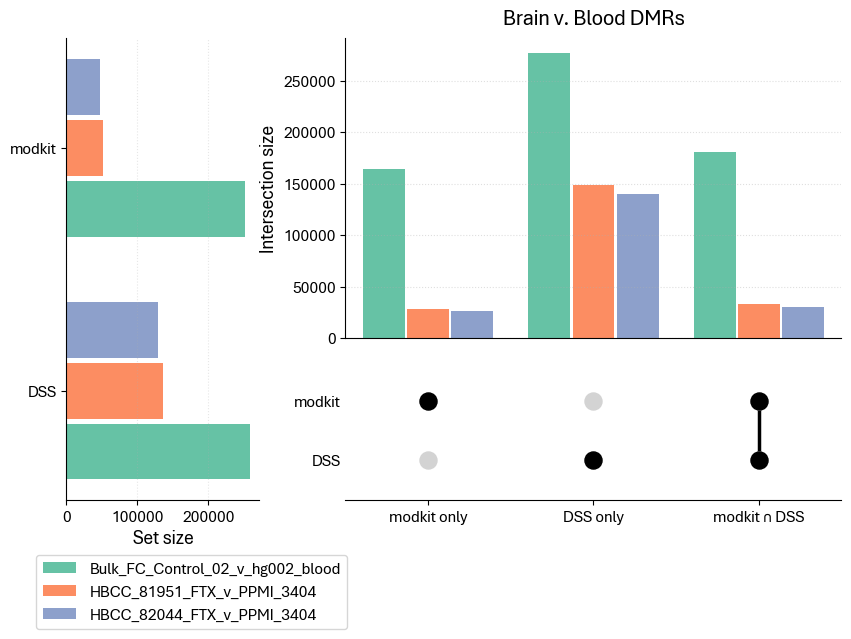

In [48]:
plot_grouped_upset_from_counts(
    counts=counts,
    set_sizes=set_sizes,
    comparison_order=comparison_order,
    colors=colors[0:3],
    title="Brain v. Blood DMRs"
)

### Get LOLA results

In [82]:
OUTDIR = '/scratch/eger/projects/MethSmoothEval/tissues/LOLA/Brain_v_Blood'

keep_cols = ['collection', 'test', 'userSet', 'filename', 
             'support', 'oddsRatio', 'pValueLog', 'qValue']

dfs = []

sample_pairs = ['Bulk_FC_Control_02_v_hg002_blood', 
               'PPMI_3404_v_HBCC_81951_FTX',
               'PPMI_3404_v_HBCC_82044_FTX']

# order for plotting
comparison_order = [
    "Bulk_FC_Control_02_v_hg002_blood",
    "HBCC_81951_FTX_v_PPMI_3404",
    "HBCC_82044_FTX_v_PPMI_3404",
]

for pair, new_name in zip(sample_pairs, comparison_order):
    fname = os.path.join(
        OUTDIR, pair, "full", "allEnrichments.tsv"
    )
    if not os.path.exists(fname):
        continue

    df = pd.read_csv(fname, sep="\t")
    df["test"] = new_name
    dfs.append(df)

df0 = pd.concat(dfs, ignore_index=True)[keep_cols].sort_values(['collection', 'test', 'userSet', 'filename'])

### SniffCell

In [116]:
df = df0[df0["collection"] == 'sniffcell'].copy()

# tidy labels
df["cell_type"] = df['filename'].astype(str).str.replace(".bed", "", regex=False)

(df.groupby(["cell_type", "test", "userSet"], as_index=False)
        .agg(or_val=("oddsRatio", "first"))
        .pivot(index="cell_type", columns=["test", "userSet"], values="or_val")
        .reindex(index=df["cell_type"].unique()))

test            Bulk_FC_Control_02_v_hg002_blood                          
userSet                                 dss_only modkit_only     shared   
cell_type                                                                 
B-cell                                  0.842539    0.292070   0.975411  \
Granulocyte                             1.709680    1.072700   2.180785   
Monocyte                                0.574675    0.041421   0.709726   
NK-cell                                 0.911251    0.314445   0.735650   
Neuron                                  6.015072    1.984732   4.837659   
Oligodendrocyte                         5.907009    3.203145  17.875460   
T-cell                                  0.976686    0.290696   1.566114   

test            HBCC_81951_FTX_v_PPMI_3404                          
userSet                           dss_only modkit_only     shared   
cell_type                                                           
B-cell                            0.981652    0.061865   0.119737  \
Granulocyte                      13.737183    7.717262  14.171441   
Monocyte                          1.412483    0.000000   0.000000   
NK-cell                           1.306984    0.153388   0.000000   
Neuron                            7.770594    1.419425   1.860110   
Oligodendrocyte                  14.504142    3.786690   6.456758   
T-cell                            1.521703    0.234407   0.134149   

test            HBCC_82044_FTX_v_PPMI_3404                         
userSet                           dss_only modkit_only     shared  
cell_type                                                          
B-cell                            1.086894    0.101050   0.132677  
Granulocyte                      16.011364    7.911390  15.617089  
Monocyte                          1.393350    0.274468   0.240096  
NK-cell                           1.406241    0.083474   0.073020  
Neuron                            7.645904    1.517129   2.079591  
Oligodendrocyte                  11.261666    2.880671   4.970705  
T-cell                            1.839601    0.255135   0.148643

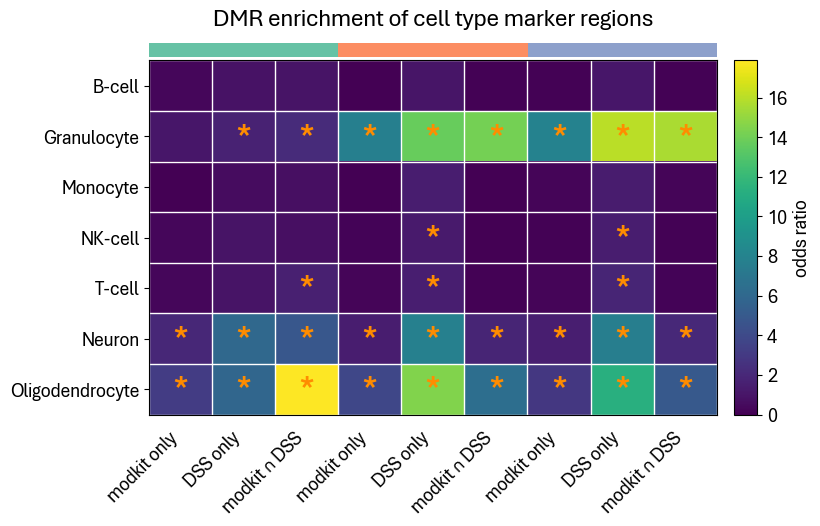

In [120]:
plot_sniffcell_heatmap(
    df0=df0,
    comparison_order=comparison_order,
    comparison_colors=colors[0:3],  # same list you pass to the UpSet plot
    x_rotation=45,
)